<a href="https://colab.research.google.com/github/elwafkiabdessamad-ship-it/master_projct_2026/blob/main/envirtox-master.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

#Load the  File

In [ ]:
FILE_PATH = "/content/envirotox_20260415204209.xlsx"

df = pd.read_excel(FILE_PATH)

print("✅ File loaded!")
print(f"   Rows    : {len(df)}")
print(f"   Columns : {df.columns.tolist()}")
print()
print(df.head())

✅ File loaded!
   Rows    : 2003
   Columns : ['CAS', 'Chemical name', 'Latin name', 'Trophic Level', 'Effect', 'Effect value', 'Unit', 'Test type', 'Test statistic', 'Duration', 'Duration (days)', 'Effect is 5X above water solubility', 'Source', 'version']

     CAS                                      Chemical name  \
0  50000                          Formaldehyde;Formaldehyde   
1  50066  Phenobarbital;5-Ethyl-5-phenyl-1,3-diazinane-2...   
2  50215                Lactic acid;2-Hydroxypropanoic acid   
3  50293  p,p'-DDT;1,1'-(2,2,2-Trichloroethane-1,1-diyl)...   
4  50306  2,6-Dichlorobenzoic acid;2,6-Dichlorobenzoic acid   

                Latin name Trophic Level     Effect  Effect value  Unit  \
0         Morone saxatilis          FISH  Mortality        59.000  mg/L   
1      Pimephales promelas          FISH  Mortality       485.000  mg/L   
2  Oreochromis mossambicus          FISH  Mortality       258.000  mg/L   
3                 Perca sp          FISH  Mortality         0.

In [ ]:
df = df[[
    'CAS',
    'Chemical name',
    'Trophic Level',
    'Effect value',       # this is the LC50 value
    'Unit',               # all are mg/L
    'Test statistic',     # all are LC50
    'Test type',          # A = acute, C = chronic
]]

print("\n✅ Columns selected!")
print(df.head())


✅ Columns selected!
     CAS                                      Chemical name Trophic Level  \
0  50000                          Formaldehyde;Formaldehyde          FISH   
1  50066  Phenobarbital;5-Ethyl-5-phenyl-1,3-diazinane-2...          FISH   
2  50215                Lactic acid;2-Hydroxypropanoic acid          FISH   
3  50293  p,p'-DDT;1,1'-(2,2,2-Trichloroethane-1,1-diyl)...          FISH   
4  50306  2,6-Dichlorobenzoic acid;2,6-Dichlorobenzoic acid          FISH   

   Effect value  Unit Test statistic Test type  
0        59.000  mg/L           LC50         A  
1       485.000  mg/L           LC50         A  
2       258.000  mg/L           LC50         A  
3         0.015  mg/L           LC50         A  
4       120.000  mg/L           LC50         A  


In [ ]:
df = df[df['Trophic Level'] == 'FISH']
print(f"\n✅ After keeping FISH only: {len(df)} rows")

# Keep only Acute tests (A)
df = df[df['Test type'] == 'A']
print(f"✅ After keeping Acute only: {len(df)} rows")



✅ After keeping FISH only: 1915 rows
✅ After keeping Acute only: 1915 rows


In [ ]:
df = df.dropna(subset=['Effect value'])

# Remove zero or negative values (impossible for toxicity)
df = df[df['Effect value'] > 0]

print(f"\n✅ After removing invalid values: {len(df)} rows")



✅ After removing invalid values: 1915 rows


In [ ]:
df['log_LC50'] = np.log10(df['Effect value'])

print("\n✅ Log transformation done!")
print(df[['CAS', 'Chemical name', 'Effect value', 'log_LC50']].head(10))



✅ Log transformation done!
      CAS                                      Chemical name  Effect value  \
0   50000                          Formaldehyde;Formaldehyde        59.000   
1   50066  Phenobarbital;5-Ethyl-5-phenyl-1,3-diazinane-2...       485.000   
2   50215                Lactic acid;2-Hydroxypropanoic acid       258.000   
3   50293  p,p'-DDT;1,1'-(2,2,2-Trichloroethane-1,1-diyl)...         0.015   
4   50306  2,6-Dichlorobenzoic acid;2,6-Dichlorobenzoic acid       120.000   
5   50317  2,3,6-Trichlorobenzoic acid;2,3,6-Trichloroben...         8.500   
7   51036  Piperonyl butoxide;5-{[2-(2-Butoxyethoxy)ethox...        11.200   
8   51285                2,4-Dinitrophenol;2,4-Dinitrophenol        11.100   
9   52517           Bronopol;2-Bromo-2-nitropropane-1,3-diol        20.000   
10  52539  Verapamil;2-(3,4-Dimethoxyphenyl)-5-{[2-(3,4-d...         2.720   

    log_LC50  
0   1.770852  
1   2.685742  
2   2.411620  
3  -1.823909  
4   2.079181  
5   0.929419  
7   1.04

**median**

In [ ]:
df = df.groupby('CAS').agg(
    Chemical_name = ('Chemical name', 'first'),
    LC50_original = ('Effect value', 'median'),
    log_LC50      = ('log_LC50', 'mean'),
    n_measurements= ('Effect value', 'count')   # how many tests were averaged
).reset_index()

print(f"\n✅ After averaging duplicates: {len(df)} unique molecules")
print(df.head(10))


✅ After averaging duplicates: 1838 unique molecules
     CAS                                      Chemical_name  LC50_original  \
0  50000                          Formaldehyde;Formaldehyde         59.000   
1  50066  Phenobarbital;5-Ethyl-5-phenyl-1,3-diazinane-2...        485.000   
2  50215                Lactic acid;2-Hydroxypropanoic acid        258.000   
3  50293  p,p'-DDT;1,1'-(2,2,2-Trichloroethane-1,1-diyl)...          0.015   
4  50306  2,6-Dichlorobenzoic acid;2,6-Dichlorobenzoic acid        120.000   
5  50317  2,3,6-Trichlorobenzoic acid;2,3,6-Trichloroben...          8.500   
6  51036  Piperonyl butoxide;5-{[2-(2-Butoxyethoxy)ethox...         11.200   
7  51285                2,4-Dinitrophenol;2,4-Dinitrophenol         11.100   
8  52517           Bronopol;2-Bromo-2-nitropropane-1,3-diol         20.000   
9  52539  Verapamil;2-(3,4-Dimethoxyphenyl)-5-{[2-(3,4-d...          2.720   

   log_LC50  n_measurements  
0  1.770852               1  
1  2.685742               1 

In [ ]:
df['CAS_str'] = df['CAS'].astype(str)

print("\n✅ CAS converted to string:")
print(df[['CAS', 'CAS_str']].head())



✅ CAS converted to string:
     CAS CAS_str
0  50000   50000
1  50066   50066
2  50215   50215
3  50293   50293
4  50306   50306


#Install & Import

In [ ]:
!pip install pubchempy
!pip install rdkit
import pubchempy as pcp
import pandas as pd
import numpy as np
from rdkit import Chem
import time

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 48.4 MB/s eta 0:00:00


#Fix Both Problems CAS (50000 to 50-00-0)

In [ ]:
import pubchempy as pcp
import time

# ── Fix 1: CAS format ──────────────────────────────────────
def int_to_cas(cas_val):
    try:
        s = str(int(cas_val))
        return f"{s[:-3]}-{s[-3:-1]}-{s[-1]}"
    except ValueError:
        return str(cas_val) # Return original value if it cannot be converted to int

# ── Fix 2: Clean chemical name (take first part only) ──────
def clean_name(name):
    return str(name).split(';')[0].strip()

# Apply both fixes
df['CAS_str']      = df['CAS'].apply(int_to_cas)
df['Chemical_name'] = df['Chemical_name'].apply(clean_name)

# Verify fixes
print("✅ Fixes applied:")
print(df[['CAS', 'CAS_str', 'Chemical_name']].head(5))

✅ Fixes applied:
     CAS  CAS_str             Chemical_name
0  50000  50-00-0              Formaldehyde
1  50066  50-06-6             Phenobarbital
2  50215  50-21-5               Lactic acid
3  50293  50-29-3                  p,p'-DDT
4  50306  50-30-6  2,6-Dichlorobenzoic acid


#Test on 30 molecules

In [ ]:
# ── Fetch SMILES: try CAS first, then name ─────────────────
def get_smiles(cas_str, name):
    # Try with CAS number first
    try:
        results = pcp.get_compounds(cas_str, 'name')
        if results:
            return results[0].isomeric_smiles
    except:
        pass

    # If not found → try with chemical name
    try:
        results = pcp.get_compounds(name, 'name')
        if results:
            return results[0].isomeric_smiles
    except:
        pass

    return None

# ── Test on 30 molecules ────────────────────────────────────
df_test = df.head(30).copy()
smiles_list = []

for i, row in df_test.iterrows():
    smi = get_smiles(row['CAS_str'], row['Chemical_name'])
    smiles_list.append(smi)
    print(f"{len(smiles_list)}/30 | {row['CAS_str']} | {smi}")
    time.sleep(0.3)

df_test['SMILES'] = smiles_list

found   = df_test['SMILES'].notna().sum()
missing = df_test['SMILES'].isna().sum()
print(f"\n✅ Done! Found: {found}/30 | Missing: {missing}/30")

/tmp/ipykernel_1028/597707158.py:7: PubChemPyDeprecationWarning: isomeric_smiles is deprecated: Use smiles instead
  return results[0].isomeric_smiles


1/30 | 50-00-0 | C=O
2/30 | 50-06-6 | CCC1(C(=O)NC(=O)NC1=O)C2=CC=CC=C2
3/30 | 50-21-5 | CC(C(=O)O)O
4/30 | 50-29-3 | C1=CC(=CC=C1C(C2=CC=C(C=C2)Cl)C(Cl)(Cl)Cl)Cl
5/30 | 50-30-6 | C1=CC(=C(C(=C1)Cl)C(=O)O)Cl
6/30 | 50-31-7 | C1=CC(=C(C(=C1Cl)C(=O)O)Cl)Cl
7/30 | 51-03-6 | CCCCOCCOCCOCC1=CC2=C(C=C1CCC)OCO2
8/30 | 51-28-5 | C1=CC(=C(C=C1[N+](=O)[O-])[N+](=O)[O-])O
9/30 | 52-51-7 | C(C(CO)([N+](=O)[O-])Br)O
10/30 | 52-53-9 | CC(C)C(CCCN(C)CCC1=CC(=C(C=C1)OC)OC)(C#N)C2=CC(=C(C=C2)OC)OC
11/30 | 52-68-6 | COP(=O)(C(C(Cl)(Cl)Cl)O)OC
12/30 | 53-86-1 | CC1=C(C2=C(N1C(=O)C3=CC=C(C=C3)Cl)C=CC(=C2)OC)CC(=O)O
13/30 | 54-11-5 | CN1CCC[C@H]1C2=CN=CC=C2
14/30 | 54-21-7 | C1=CC=C(C(=C1)C(=O)[O-])O.[Na+]
15/30 | 55-18-5 | CCN(CC)N=O
16/30 | 55-37-8 | CC1=CC(=CC(=C1SC)C)OP(=S)(OC)OC
17/30 | 55-38-9 | CC1=C(C=CC(=C1)OP(=S)(OC)OC)SC
18/30 | 55-63-0 | C(C(CO[N+](=O)[O-])O[N+](=O)[O-])O[N+](=O)[O-]
19/30 | 55-86-7 | CN(CCCl)CCCl.Cl
20/30 | 56-23-5 | C(Cl)(Cl)(Cl)Cl
21/30 | 56-35-9 | CCCC[Sn](CCCC)(CCCC)O[Sn](

#ignore the deprecation warning:

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Full Dataset

In [ ]:
smiles_list = []

for i, row in df.iterrows():
    smi = get_smiles(row['CAS_str'], row['Chemical_name'])
    smiles_list.append(smi)

    # Print progress every 50
    if len(smiles_list) % 50 == 0:
        found = sum(x is not None for x in smiles_list)
        print(f"✅ {len(smiles_list)}/{len(df)} | Found: {found}")

    # Save every 100
    if len(smiles_list) % 100 == 0:
        df_temp = df.copy()
        df_temp['SMILES'] = smiles_list + [None] * (len(df) - len(smiles_list))
        df_temp.to_csv("dataset_partial.csv", index=False)
        print(f"   💾 Saved at {len(smiles_list)}")

    time.sleep(0.3)

# Add to dataframe
df['SMILES'] = smiles_list

# Final summary
found   = df['SMILES'].notna().sum()
missing = df['SMILES'].isna().sum()
print(f"\n🎉 Done!")
print(f"   Total   : {len(df)}")
print(f"   Found   : {found}")
print(f"   Missing : {missing}")

✅ 50/1838 | Found: 50
✅ 100/1838 | Found: 100
   💾 Saved at 100
✅ 150/1838 | Found: 150
✅ 200/1838 | Found: 200
   💾 Saved at 200
✅ 250/1838 | Found: 250
✅ 300/1838 | Found: 300
   💾 Saved at 300
✅ 350/1838 | Found: 350
✅ 400/1838 | Found: 400
   💾 Saved at 400
✅ 450/1838 | Found: 450
✅ 500/1838 | Found: 500
   💾 Saved at 500
✅ 550/1838 | Found: 550
✅ 600/1838 | Found: 600
   💾 Saved at 600
✅ 650/1838 | Found: 650
✅ 700/1838 | Found: 700
   💾 Saved at 700
✅ 750/1838 | Found: 750
✅ 800/1838 | Found: 800
   💾 Saved at 800
✅ 850/1838 | Found: 850
✅ 900/1838 | Found: 899
   💾 Saved at 900
✅ 950/1838 | Found: 945
✅ 1000/1838 | Found: 995
   💾 Saved at 1000
✅ 1050/1838 | Found: 1045
✅ 1100/1838 | Found: 1095
   💾 Saved at 1100
✅ 1150/1838 | Found: 1145
✅ 1200/1838 | Found: 1195
   💾 Saved at 1200
✅ 1250/1838 | Found: 1232
✅ 1300/1838 | Found: 1282
   💾 Saved at 1300
✅ 1350/1838 | Found: 1332
✅ 1400/1838 | Found: 1382
   💾 Saved at 1400
✅ 1450/1838 | Found: 1431
✅ 1500/1838 | Found: 1478
   💾

#Remove Missing SMILES

In [ ]:
# Before
print(f"Before: {len(df)} molecules")

# Remove rows with no SMILES
df = df.dropna(subset=['SMILES'])

# After
print(f"After:  {len(df)} molecules")
print(f"Removed: 60 molecules with no SMILES")

Before: 1838 molecules
After:  1778 molecules
Removed: 60 molecules with no SMILES


#Validate SMILES with RDKit

In [ ]:
from rdkit import Chem

def is_valid(smi):
    mol = Chem.MolFromSmiles(smi)
    return mol is not None

# Check each SMILES
df['valid'] = df['SMILES'].apply(is_valid)

invalid = df[df['valid'] == False]
print(f"Invalid SMILES: {len(invalid)}")
print(invalid[['CAS_str', 'Chemical_name', 'SMILES']])

# Keep only valid ones
df = df[df['valid'] == True]
df = df.drop(columns=['valid'])

print(f"\n✅ Final molecules: {len(df)}")

Invalid SMILES: 0
Empty DataFrame
Columns: [CAS_str, Chemical_name, SMILES]
Index: []

✅ Final molecules: 1778


[14:10:53] WARNING: not removing hydrogen atom without neighbors
[14:10:53] WARNING: not removing hydrogen atom without neighbors
[14:10:53] WARNING: not removing hydrogen atom without neighbors


#Save Final CSV

In [ ]:
# Keep only useful columns
df_final = df[[
    'CAS',
    'CAS_str',
    'Chemical_name',
    'log_LC50',
    'n_measurements',
    'SMILES'
]]

# Save
df_final.to_csv("dataset_final.csv", index=False)

print("✅ Final dataset saved → dataset_final.csv")
print(f"   Total molecules : {len(df_final)}")
print()
print(df_final.head(10))

✅ Final dataset saved → dataset_final.csv
   Total molecules : 1778

     CAS  CAS_str                Chemical_name  log_LC50  n_measurements  \
0  50000  50-00-0                 Formaldehyde  1.770852               1   
1  50066  50-06-6                Phenobarbital  2.685742               1   
2  50215  50-21-5                  Lactic acid  2.411620               1   
3  50293  50-29-3                     p,p'-DDT -1.823909               1   
4  50306  50-30-6     2,6-Dichlorobenzoic acid  2.079181               1   
5  50317  50-31-7  2,3,6-Trichlorobenzoic acid  0.929419               1   
6  51036  51-03-6           Piperonyl butoxide  1.049218               1   
7  51285  51-28-5            2,4-Dinitrophenol  1.045323               1   
8  52517  52-51-7                     Bronopol  1.301030               1   
9  52539  52-53-9                    Verapamil  0.434569               1   

                                              SMILES  
0                                      

#Quick Check of Your Final Data

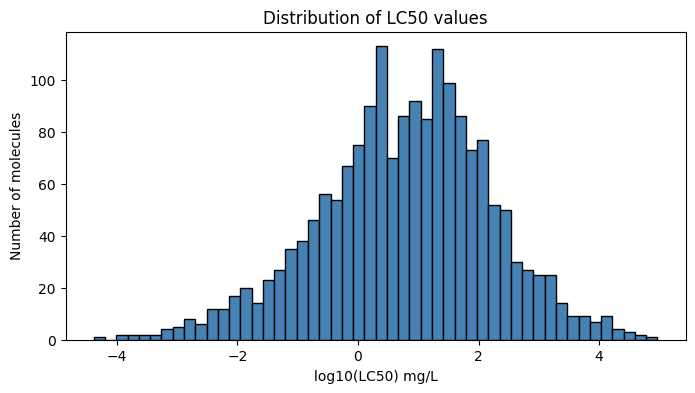

 Statistics:
count    1778.000000
mean        0.774737
std         1.432252
min        -4.376751
25%        -0.101007
50%         0.870694
75%         1.716003
max         4.966142
Name: log_LC50, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

# Distribution of LC50 values
plt.figure(figsize=(8, 4))
plt.hist(df_final['log_LC50'], bins=50, color='steelblue', edgecolor='black')
plt.xlabel("log10(LC50) mg/L")
plt.ylabel("Number of molecules")
plt.title("Distribution of LC50 values")
plt.show()

# Stats
print(" Statistics:")
print(df_final['log_LC50'].describe())

#Install PyTorch Geometric

In [ ]:
!pip install torch torchvision
!pip install torch-geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.0 MB/s eta 0:00:00


#Import Everything

In [ ]:
import torch
from torch_geometric.data import Data
from rdkit import Chem
import pandas as pd
import numpy as np

print(f"✅ PyTorch version: {torch.__version__}")
print("✅ All libraries imported!")

✅ PyTorch version: 2.10.0+cpu
✅ All libraries imported!


# Define Atom Features

In [ ]:
def get_atom_features(atom):
    """
    Extract features from one atom
    Returns a list of numbers
    """
    features = [
        atom.GetAtomicNum(),          # Atomic number: C=6, N=7, O=8...
        atom.GetDegree(),             # Number of bonds
        atom.GetTotalNumHs(),         # Number of H attached
        atom.GetFormalCharge(),       # Electric charge
        int(atom.GetIsAromatic()),    # Aromatic? 1=yes, 0=no
        int(atom.IsInRing()),         # In a ring? 1=yes, 0=no
    ]
    return features

# Test on one atom
mol = Chem.MolFromSmiles("CCO")  # Ethanol
atom = mol.GetAtomWithIdx(0)     # First atom (Carbon)
print("Atom features:", get_atom_features(atom))
print("Feature meaning: [atomic_num, degree, num_H, charge, aromatic, in_ring]")

Atom features: [6, 1, 3, 0, 0, 0]
Feature meaning: [atomic_num, degree, num_H, charge, aromatic, in_ring]


# Define Bond Features

In [ ]:
def get_bond_features(bond):
    """
    Extract features from one bond
    Returns a list of numbers
    """
    bond_type = bond.GetBondTypeAsDouble()
    # 1.0 = single, 1.5 = aromatic, 2.0 = double, 3.0 = triple

    features = [
        bond_type,
        int(bond.IsInRing()),         # Bond in a ring?
        int(bond.GetIsConjugated()),  # Conjugated bond?
    ]
    return features

# Test on one bond
bond = mol.GetBondWithIdx(0)   # First bond C-C
print("Bond features:", get_bond_features(bond))
print("Feature meaning: [bond_type, in_ring, conjugated]")

Bond features: [1.0, 0, 0]
Feature meaning: [bond_type, in_ring, conjugated]


# Convert One SMILES to Graph

In [ ]:
def smiles_to_graph(smiles, label):
    """
    Convert a SMILES string to a PyTorch Geometric graph

    Input:  SMILES string + LC50 value
    Output: Data object (graph)
    """
    # Step 1: SMILES → RDKit molecule
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Step 2: Get atom features (nodes)
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append(get_atom_features(atom))

    # Convert to tensor
    x = torch.tensor(atom_features, dtype=torch.float)

    # Step 3: Get bond features (edges)
    edge_index = []   # which atoms are connected
    edge_attr  = []   # bond features

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        # Add both directions (graph is undirected)
        edge_index += [[i, j], [j, i]]
        feat = get_bond_features(bond)
        edge_attr  += [feat, feat]

    edge_index = torch.tensor(edge_index, dtype=torch.long).t()
    edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)

    # Step 4: Label (LC50 value)
    y = torch.tensor([label], dtype=torch.float)

    # Step 5: Create graph object
    graph = Data(x=x, edge_index=edge_index,
                 edge_attr=edge_attr, y=y)
    return graph


# ── Test on one molecule ────────────────────────────────────
smiles = "CCO"   # Ethanol
label  = 1.5     # Example log_LC50

graph = smiles_to_graph(smiles, label)

print("✅ Graph created!")
print(f"   Atoms (nodes) : {graph.x.shape[0]}")
print(f"   Atom features : {graph.x.shape[1]}")
print(f"   Bonds (edges) : {graph.edge_index.shape[1]}")
print(f"   Label (LC50)  : {graph.y}")
print(f"\n   Node features:\n{graph.x}")

✅ Graph created!
   Atoms (nodes) : 3
   Atom features : 6
   Bonds (edges) : 4
   Label (LC50)  : tensor([1.5000])

   Node features:
tensor([[6., 1., 3., 0., 0., 0.],
        [6., 2., 2., 0., 0., 0.],
        [8., 1., 1., 0., 0., 0.]])


# Convert ALL Molecules

In [ ]:
from torch_geometric.data import Data

dataset = []
failed  = 0

for _, row in df_final.iterrows():
    graph = smiles_to_graph(row['SMILES'], row['log_LC50'])

    if graph is not None:
        dataset.append(graph)
    else:
        failed += 1

print(f"✅ Graphs created : {len(dataset)}")
print(f"   Failed         : {failed}")
print(f"\nExample graph:")
print(dataset[0])

[14:12:11] WARNING: not removing hydrogen atom without neighbors
[14:12:11] WARNING: not removing hydrogen atom without neighbors
[14:12:11] WARNING: not removing hydrogen atom without neighbors


✅ Graphs created : 1778
   Failed         : 0

Example graph:
Data(x=[2, 6], edge_index=[2, 2], edge_attr=[2, 3], y=[1])


# Save the Dataset

In [ ]:
import torch

torch.save(dataset, "molecular_graphs.pt")
print(f"✅ Dataset saved → molecular_graphs.pt")
print(f"   {len(dataset)} molecular graphs ready for GNN!")

✅ Dataset saved → molecular_graphs.pt
   1778 molecular graphs ready for GNN!


# Split Dataset

In [ ]:
import random
from torch_geometric.loader import DataLoader

# Shuffle dataset
random.shuffle(dataset)

# Split 80% train / 10% validation / 10% test
total      = len(dataset)
train_end  = int(0.8 * total)
val_end    = int(0.9 * total)

train_set  = dataset[:train_end]
val_set    = dataset[train_end:val_end]
test_set   = dataset[val_end:]

print(f"✅ Split done!")
print(f"   Train      : {len(train_set)}")
print(f"   Validation : {len(val_set)}")
print(f"   Test       : {len(test_set)}")

# Create loaders (feed data to model in batches)
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32)
test_loader  = DataLoader(test_set,  batch_size=32)

✅ Split done!
   Train      : 1422
   Validation : 178
   Test       : 178


# Build the GAT Model

In [ ]:
import torch
import torch.nn as nn
from torch_geometric.nn import GATConv, global_mean_pool

class GATModel(nn.Module):
    def __init__(self):
        super().__init__()

        # GAT layers (graph learning)
        self.conv1 = GATConv(6, 64, heads=4, concat=True)
        self.conv2 = GATConv(64*4, 64, heads=4, concat=True)
        self.conv3 = GATConv(64*4, 64, heads=1, concat=False)

        # Activation & regularization
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

        # Final prediction layer
        self.output  = nn.Linear(64, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Layer 1: atoms learn from neighbors
        x = self.conv1(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)

        # Layer 2: atoms learn more
        x = self.conv2(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)

        # Layer 3: refine
        x = self.conv3(x, edge_index)
        x = self.relu(x)

        # Readout: combine all atoms → one vector per molecule
        x = global_mean_pool(x, batch)

        # Predict LC50
        out = self.output(x)
        return out.squeeze()

# Create model
model = GATModel()
print("✅ Model created!")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

✅ Model created!
GATModel(
  (conv1): GATConv(6, 64, heads=4)
  (conv2): GATConv(256, 64, heads=4)
  (conv3): GATConv(256, 64, heads=1)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (output): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 85249


 # Setup Training

In [ ]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

print("✅ Training setup ready!")
print(f"   Loss      : MSE (Mean Squared Error)")
print(f"   Optimizer : Adam  (lr=0.001)")

✅ Training setup ready!
   Loss      : MSE (Mean Squared Error)
   Optimizer : Adam  (lr=0.001)


# Train the Model

In [ ]:
import numpy as np

def train_one_epoch():
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        predictions = model(batch)
        loss = criterion(predictions, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def evaluate(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            predictions = model(batch)
            loss = criterion(predictions, batch.y)
            total_loss += loss.item()
    return total_loss / len(loader)

# ── Training Loop ───────────────────────────────────────────
EPOCHS = 100
best_val_loss = float('inf')

train_losses = []
val_losses   = []

print("⏳ Training started...")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'RMSE':>8}")
print("-" * 45)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch()
    val_loss   = evaluate(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")

    # Print every 10 epochs
    if epoch % 10 == 0:
        rmse = np.sqrt(val_loss)
        print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | {rmse:>8.4f}")

print("\n✅ Training complete!")
print(f"   Best validation loss : {best_val_loss:.4f}")
print(f"   Best RMSE            : {np.sqrt(best_val_loss):.4f}")

⏳ Training started...
 Epoch | Train Loss |   Val Loss |     RMSE
---------------------------------------------
    10 |     1.7567 |     1.9469 |   1.3953
    20 |     1.5584 |     1.8294 |   1.3526
    30 |     1.3765 |     1.6934 |   1.3013
    40 |     1.2706 |     1.5798 |   1.2569
    50 |     1.2435 |     1.5305 |   1.2371
    60 |     1.0985 |     1.4901 |   1.2207
    70 |     1.0265 |     1.4650 |   1.2104
    80 |     0.9857 |     1.4324 |   1.1968
    90 |     0.9612 |     1.4511 |   1.2046
   100 |     0.9286 |     1.4630 |   1.2096

✅ Training complete!
   Best validation loss : 1.4324
   Best RMSE            : 1.1968


# Plot Training Curve

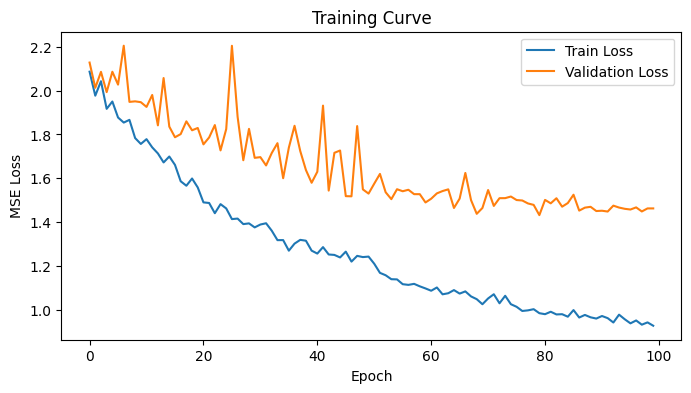

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Curve")
plt.legend()
plt.show()

# Final Evaluation on Test Set

✅ Final Results on Test Set:
   RMSE : 1.0757
   R²   : 0.3913


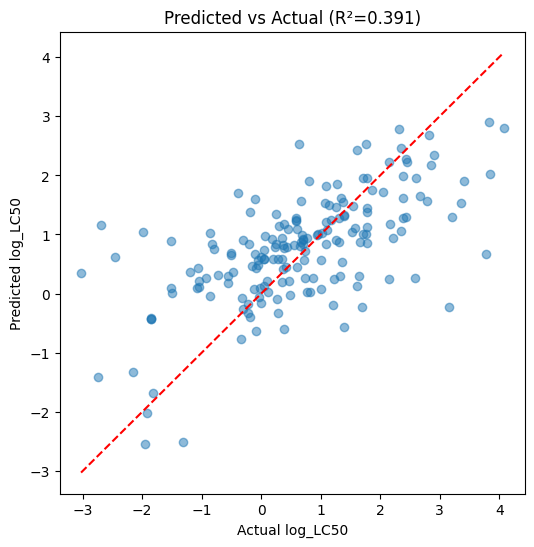

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Load best model
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for batch in test_loader:
        preds = model(batch)
        y_true.extend(batch.y.tolist())
        y_pred.extend(preds.tolist())

# Metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)

print("✅ Final Results on Test Set:")
print(f"   RMSE : {rmse:.4f}")
print(f"   R²   : {r2:.4f}")

# Plot predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)],
         [min(y_true), max(y_true)], 'r--')
plt.xlabel("Actual log_LC50")
plt.ylabel("Predicted log_LC50")
plt.title(f"Predicted vs Actual (R²={r2:.3f})")
plt.show()

# Train Longer (more epochs)

In [ ]:
# Change this in Cell 23
EPOCHS = 300  # instead of 100

# STEP 1: Update atom features (9 features now)
#STEP 2: Rebuild all graphs
# STEP 3: Re-split dataset
# STEP 4: Build improved model
# STEP 5: Train 300 epochs
# STEP 6: Evaluate on test set

In [ ]:
# ── STEP 1: Update atom features (9 features now) ──────────
def get_atom_features(atom):
    features = [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetTotalNumHs(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        int(atom.IsInRing()),
        atom.GetTotalValence(),
        int(atom.GetHybridization()),
        atom.GetMass() / 100.0,
    ]
    return features

def get_bond_features(bond):
    features = [
        bond.GetBondTypeAsDouble(),
        int(bond.IsInRing()),
        int(bond.GetIsConjugated()),
    ]
    return features

def smiles_to_graph(smiles, label):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append(get_atom_features(atom))
    x = torch.tensor(atom_features, dtype=torch.float)
    edge_index = []
    edge_attr  = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]
        feat = get_bond_features(bond)
        edge_attr  += [feat, feat]
    edge_index = torch.tensor(edge_index, dtype=torch.long).t()
    edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)
    y = torch.tensor([label], dtype=torch.float)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# ── STEP 2: Rebuild all graphs ──────────────────────────────
dataset = []
failed  = 0
for _, row in df_final.iterrows():
    graph = smiles_to_graph(row['SMILES'], row['log_LC50'])
    if graph is not None:
        dataset.append(graph)
    else:
        failed += 1
print(f"✅ Graphs rebuilt: {len(dataset)} | Failed: {failed}")

# ── STEP 3: Re-split dataset ────────────────────────────────
import random
from torch_geometric.loader import DataLoader
random.shuffle(dataset)
total     = len(dataset)
train_end = int(0.8 * total)
val_end   = int(0.9 * total)
train_set = dataset[:train_end]
val_set   = dataset[train_end:val_end]
test_set  = dataset[val_end:]
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32)
test_loader  = DataLoader(test_set,  batch_size=32)
print(f"✅ Split: Train={len(train_set)} Val={len(val_set)} Test={len(test_set)}")

# ── STEP 4: Build improved model ────────────────────────────
import torch.nn as nn
from torch_geometric.nn import GATConv, global_mean_pool

class GATModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1   = GATConv(9, 128, heads=4, concat=True)
        self.conv2   = GATConv(128*4, 128, heads=4, concat=True)
        self.conv3   = GATConv(128*4, 128, heads=1, concat=False)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc1     = nn.Linear(128, 64)
        self.fc2     = nn.Linear(64, 32)
        self.output  = nn.Linear(32, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv3(x, edge_index)
        x = self.relu(x)
        x = global_mean_pool(x, batch)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        return self.output(x).squeeze()

model = GATModel()
print(f"✅ Model ready! Parameters: {sum(p.numel() for p in model.parameters())}")

# ── STEP 5: Train 300 epochs ────────────────────────────────
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np

criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, patience=10, factor=0.5, min_lr=1e-6)

EPOCHS = 300
best_val_loss = float('inf')
train_losses  = []
val_losses    = []

print("⏳ Training started...")
print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Val Loss':>10} | {'RMSE':>8}")
print("-" * 45)

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        preds = model(batch)
        loss  = criterion(preds, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)

    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            preds = model(batch)
            loss  = criterion(preds, batch.y)
            total_loss += loss.item()
    val_loss = total_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")

    if epoch % 30 == 0:
        print(f"{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | {np.sqrt(val_loss):>8.4f}")

print(f"\n✅ Training complete!")
print(f"   Best RMSE : {np.sqrt(best_val_loss):.4f}")

# ── STEP 6: Evaluate on test set ────────────────────────────
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

model.load_state_dict(torch.load("best_model.pt"))
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for batch in test_loader:
        preds = model(batch)
        y_true.extend(batch.y.tolist())
        y_pred.extend(preds.tolist())

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
print(f"\n🎯 Final Results:")
print(f"   RMSE : {rmse:.4f}")
print(f"   R²   : {r2:.4f}")

plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel("Actual log_LC50")
plt.ylabel("Predicted log_LC50")
plt.title(f"Predicted vs Actual (R²={r2:.3f})")
plt.show()

[15:35:18] WARNING: not removing hydrogen atom without neighbors
[15:35:18] WARNING: not removing hydrogen atom without neighbors
[15:35:18] WARNING: not removing hydrogen atom without neighbors


✅ Graphs rebuilt: 1778 | Failed: 0
✅ Split: Train=1422 Val=178 Test=178
✅ Model ready! Parameters: 346113
⏳ Training started...
 Epoch | Train Loss |   Val Loss |     RMSE
---------------------------------------------
    30 |     1.4440 |     1.6005 |   1.2651
    60 |     1.1271 |     1.4368 |   1.1986


KeyboardInterrupt: 

# 1778 molecules is a small dataset for a 346k parameter model.

Solution 1 — Smaller Model + BatchNorm

In [ ]:
from torch_geometric.nn import GATConv, global_mean_pool, BatchNorm

class GATModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = GATConv(9, 64, heads=4, concat=True)
        self.bn1   = BatchNorm(64*4)

        self.conv2 = GATConv(64*4, 64, heads=2, concat=True)
        self.bn2   = BatchNorm(64*2)

        self.conv3 = GATConv(64*2, 64, heads=1, concat=False)

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

        self.fc1    = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = self.relu(x)

        x = global_mean_pool(x, batch)
        x = self.relu(self.fc1(x))
        return self.output(x).squeeze()

model = GATModel()
print(f"✅ Parameters: {sum(p.numel() for p in model.parameters())}")

✅ Parameters: 47489


Solution 2 — Add Morgan Fingerprints as Extra Features

In [ ]:
from rdkit.Chem import AllChem

def smiles_to_graph(smiles, label):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Atom features (same as before)
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append(get_atom_features(atom))
    x = torch.tensor(atom_features, dtype=torch.float)

    # Edge features (same as before)
    edge_index = []
    edge_attr  = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]
        feat = get_bond_features(bond)
        edge_attr  += [feat, feat]
    edge_index = torch.tensor(edge_index, dtype=torch.long).t()
    edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)

    # ── NEW: Morgan fingerprint as global molecule feature ──
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=128)
    fp_tensor = torch.tensor(list(fp), dtype=torch.float)

    y = torch.tensor([label], dtype=torch.float)
    return Data(x=x, edge_index=edge_index,
                edge_attr=edge_attr, y=y, fp=fp_tensor)

Then update model to use fingerprints:

In [ ]:
class GATModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = GATConv(9, 64, heads=4, concat=True)
        self.bn1   = BatchNorm(64*4)
        self.conv2 = GATConv(64*4, 64, heads=2, concat=True)
        self.bn2   = BatchNorm(64*2)
        self.conv3 = GATConv(64*2, 64, heads=1, concat=False)

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

        # 64 from GNN + 128 from fingerprint
        self.fc1    = nn.Linear(64 + 128, 64)
        self.fc2    = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = self.relu(x)

        x = global_mean_pool(x, batch)

        # Combine GNN output + fingerprint
        x = torch.cat([x, data.fp], dim=1)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        return self.output(x).squeeze()

model = GATModel()
print(f"✅ Parameters: {sum(p.numel() for p in model.parameters())}")

✅ Parameters: 59841


# Solution 3 — Retrain with Better Settings

In [ ]:
# Rebuild dataset with fingerprints
dataset = []
for _, row in df_final.iterrows():
    graph = smiles_to_graph(row['SMILES'], row['log_LC50'])
    if graph is not None:
        dataset.append(graph)
print(f"✅ Dataset rebuilt: {len(dataset)}")

# Re-split
random.shuffle(dataset)
total     = len(dataset)
train_end = int(0.8 * total)
val_end   = int(0.9 * total)
train_set = dataset[:train_end]
val_set   = dataset[train_end:val_end]
test_set  = dataset[val_end:]

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32)
test_loader  = DataLoader(test_set,  batch_size=32)

# Train
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, patience=15, factor=0.5)

EPOCHS        = 300
best_val_loss = float('inf')
train_losses  = []
val_losses    = []

print("⏳ Training...")
print(f"{'Epoch':>6} | {'Train':>8} | {'Val':>8} | {'RMSE':>8}")
print("-" * 40)

for epoch in range(1, EPOCHS + 1):
    model.train()
    total = 0
    for batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(batch), batch.y)
        loss.backward()
        optimizer.step()
        total += loss.item()
    train_loss = total / len(train_loader)

    model.eval()
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            loss = criterion(model(batch), batch.y)
            total += loss.item()
    val_loss = total / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")

    if epoch % 30 == 0:
        print(f"{epoch:>6} | {train_loss:>8.4f} | {val_loss:>8.4f} | {np.sqrt(val_loss):>8.4f}")

print(f"\n✅ Done! Best RMSE: {np.sqrt(best_val_loss):.4f}")

[15:32:44] DEPRECATION WARNING: please use MorganGenerator
[15:32:44] DEPRECATION WARNING: please use MorganGenerator
[15:32:44] DEPRECATION WARNING: please use MorganGenerator
[15:32:44] DEPRECATION WARNING: please use MorganGenerator
[15:32:44] DEPRECATION WARNING: please use MorganGenerator
[15:32:44] DEPRECATION WARNING: please use MorganGenerator
[15:32:44] DEPRECATION WARNING: please use MorganGenerator
[15:32:44] DEPRECATION WARNING: please use MorganGenerator
[15:32:44] DEPRECATION WARNING: please use MorganGenerator
[15:32:44] DEPRECATION WARNING: please use MorganGenerator
[15:32:44] DEPRECATION WARNING: please use MorganGenerator
[15:32:44] DEPRECATION WARNING: please use MorganGenerator
[15:32:44] DEPRECATION WARNING: please use MorganGenerator
[15:32:44] DEPRECATION WARNING: please use MorganGenerator
[15:32:44] DEPRECATION WARNING: please use MorganGenerator
[15:32:44] DEPRECATION WARNING: please use MorganGenerator
[15:32:44] DEPRECATION WARNING: please use MorganGenerat

✅ Dataset rebuilt: 1778
⏳ Training...
 Epoch |    Train |      Val |     RMSE
----------------------------------------


[15:32:46] DEPRECATION WARNING: please use MorganGenerator
[15:32:46] DEPRECATION WARNING: please use MorganGenerator
[15:32:46] DEPRECATION WARNING: please use MorganGenerator
[15:32:46] DEPRECATION WARNING: please use MorganGenerator
[15:32:46] DEPRECATION WARNING: please use MorganGenerator
[15:32:46] DEPRECATION WARNING: please use MorganGenerator
[15:32:46] DEPRECATION WARNING: please use MorganGenerator
[15:32:46] DEPRECATION WARNING: please use MorganGenerator
[15:32:46] DEPRECATION WARNING: please use MorganGenerator
[15:32:46] DEPRECATION WARNING: please use MorganGenerator
[15:32:46] DEPRECATION WARNING: please use MorganGenerator
[15:32:46] DEPRECATION WARNING: please use MorganGenerator
[15:32:46] DEPRECATION WARNING: please use MorganGenerator
[15:32:46] DEPRECATION WARNING: please use MorganGenerator
[15:32:46] DEPRECATION WARNING: please use MorganGenerator
[15:32:46] DEPRECATION WARNING: please use MorganGenerator
[15:32:46] DEPRECATION WARNING: please use MorganGenerat

RuntimeError: Tensors must have same number of dimensions: got 2 and 1

# Replace Only These Two Parts:
Fix 1: In smiles_to_graph — fix fingerprint

In [ ]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["RDKIT_LOG_LEVEL"] = "ERROR"

In [ ]:
from rdkit.Chem import rdFingerprintGenerator

def smiles_to_graph(smiles, label):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Atom features
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append(get_atom_features(atom))
    x = torch.tensor(atom_features, dtype=torch.float)

    # Bond features
    edge_index = []
    edge_attr  = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]
        feat = get_bond_features(bond)
        edge_attr  += [feat, feat]
    edge_index = torch.tensor(edge_index, dtype=torch.long).t()
    edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)

    # ── Fix: use MorganGenerator + correct shape ────────────
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=128)
    fp  = gen.GetFingerprintAsNumPy(mol)
    fp_tensor = torch.tensor(fp, dtype=torch.float).unsqueeze(0)  # shape [1, 128]

    y = torch.tensor([label], dtype=torch.float)
    return Data(x=x, edge_index=edge_index,
                edge_attr=edge_attr, y=y, fp=fp_tensor)

# Fix 2: In model.forward — fix concatenation

In [ ]:
def forward(self, data):
    x, edge_index, batch = data.x, data.edge_index, data.batch

    x = self.conv1(x, edge_index)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.dropout(x)

    x = self.conv2(x, edge_index)
    x = self.bn2(x)
    x = self.relu(x)
    x = self.dropout(x)

    x = self.conv3(x, edge_index)
    x = self.relu(x)

    x = global_mean_pool(x, batch)

    # ── Fix: squeeze fp to [batch_size, 128] ────────────────
    fp = data.fp.view(x.shape[0], -1)

    x = torch.cat([x, fp], dim=1)

    x = self.relu(self.fc1(x))
    x = self.dropout(x)
    x = self.relu(self.fc2(x))
    return self.output(x).squeeze()

#  Silence the Warnings

#Real Fix — Simpler Model + Strong Regularization

The model memorized the training data instead of learning general patterns. This is the main problem now.

In [ ]:
import warnings, os
warnings.filterwarnings("ignore")
os.environ["RDKIT_LOG_LEVEL"] = "ERROR"

import torch
import torch.nn as nn
import random
import numpy as np
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.nn import GATConv, global_mean_pool, BatchNorm
from torch_geometric.loader import DataLoader
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ── 1. Re-split ─────────────────────────────────────────────
random.shuffle(dataset)
total     = len(dataset)
train_end = int(0.8 * total)
val_end   = int(0.9 * total)
train_set = dataset[:train_end]
val_set   = dataset[train_end:val_end]
test_set  = dataset[val_end:]

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=64)
test_loader  = DataLoader(test_set,  batch_size=64)
print(f"✅ Split: Train={len(train_set)} Val={len(val_set)} Test={len(test_set)}")

# ── 2. Much simpler model ────────────────────────────────────
class GATModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Smaller GAT layers
        self.conv1 = GATConv(9, 32, heads=4, concat=True)
        self.bn1   = BatchNorm(32*4)
        self.conv2 = GATConv(32*4, 32, heads=2, concat=False)
        self.bn2   = BatchNorm(32)

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.5)  # stronger dropout

        # Simple output head (no fingerprint)
        self.fc1    = nn.Linear(32, 16)
        self.output = nn.Linear(16, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = self.relu(x)

        x = global_mean_pool(x, batch)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        return self.output(x).squeeze()

model = GATModel()
total_params = sum(p.numel() for p in model.parameters())
print(f"✅ Model ready! Parameters: {total_params}")

# ── 3. Train with stronger regularization ───────────────────
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = ReduceLROnPlateau(optimizer, patience=20,
                               factor=0.5, min_lr=1e-5)

EPOCHS        = 300
best_val_loss = float('inf')
train_losses  = []
val_losses    = []

print("⏳ Training...")
print(f"{'Epoch':>6} | {'Train':>8} | {'Val':>8} | {'RMSE':>8}")
print("-" * 40)

for epoch in range(1, EPOCHS + 1):
    # Train
    model.train()
    total = 0
    for batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(batch), batch.y)
        loss.backward()
        optimizer.step()
        total += loss.item()
    train_loss = total / len(train_loader)

    # Validate
    model.eval()
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            loss = criterion(model(batch), batch.y)
            total += loss.item()
    val_loss = total / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")

    if epoch % 30 == 0:
        print(f"{epoch:>6} | {train_loss:>8.4f} | {val_loss:>8.4f} | {np.sqrt(val_loss):>8.4f}")

print(f"\n✅ Done! Best Val RMSE: {np.sqrt(best_val_loss):.4f}")

# ── 4. Plot training curve ───────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Validation')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Curve")
plt.legend()
plt.show()

# ── 5. Test evaluation ───────────────────────────────────────
model.load_state_dict(torch.load("best_model.pt"))
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for batch in test_loader:
        preds = model(batch)
        y_true.extend(batch.y.tolist())
        y_pred.extend(preds.tolist())

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
print(f"\n🎯 Final Results:")
print(f"   RMSE : {rmse:.4f}")
print(f"   R²   : {r2:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)],
         [min(y_true), max(y_true)], 'r--')
plt.xlabel("Actual log_LC50")
plt.ylabel("Predicted log_LC50")
plt.title(f"Predicted vs Actual (R²={r2:.3f})")
plt.show()

✅ Split: Train=1422 Val=178 Test=178
✅ Model ready! Parameters: 10753
⏳ Training...
 Epoch |    Train |      Val |     RMSE
----------------------------------------


KeyboardInterrupt: 

# What to Do Next
The loss is still slowly decreasing at epoch 300 → the model needs more time. Also the model is now slightly too simple → we can make it a bit bigger.

Next Step — Train Longer + Slightly Bigger Model

In [ ]:
# ── Slightly bigger model ────────────────────────────────────
class GATModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GATConv(9, 64, heads=4, concat=True)
        self.bn1   = BatchNorm(64*4)
        self.conv2 = GATConv(64*4, 64, heads=2, concat=False)
        self.bn2   = BatchNorm(64)
        self.conv3 = GATConv(64, 32, heads=1, concat=False)

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.4)

        self.fc1    = nn.Linear(32, 16)
        self.output = nn.Linear(16, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = self.relu(x)

        x = global_mean_pool(x, batch)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        return self.output(x).squeeze()

model = GATModel()
print(f"✅ Parameters: {sum(p.numel() for p in model.parameters())}")

# ── Train 500 epochs ─────────────────────────────────────────
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
scheduler = ReduceLROnPlateau(optimizer, patience=25,
                               factor=0.5, min_lr=1e-5)

EPOCHS        = 500
best_val_loss = float('inf')
train_losses  = []
val_losses    = []

print("⏳ Training 500 epochs...")
print(f"{'Epoch':>6} | {'Train':>8} | {'Val':>8} | {'RMSE':>8}")
print("-" * 40)

for epoch in range(1, EPOCHS + 1):
    model.train()
    total = 0
    for batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(batch), batch.y)
        loss.backward()
        optimizer.step()
        total += loss.item()
    train_loss = total / len(train_loader)

    model.eval()
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            loss = criterion(model(batch), batch.y)
            total += loss.item()
    val_loss = total / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")

    if epoch % 50 == 0:
        print(f"{epoch:>6} | {train_loss:>8.4f} | {val_loss:>8.4f} | {np.sqrt(val_loss):>8.4f}")

print(f"\n✅ Done! Best Val RMSE: {np.sqrt(best_val_loss):.4f}")

# ── Plot ─────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Validation')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Curve")
plt.legend()
plt.show()

# ── Test ─────────────────────────────────────────────────────
model.load_state_dict(torch.load("best_model.pt"))
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for batch in test_loader:
        preds = model(batch)
        y_true.extend(batch.y.tolist())
        y_pred.extend(preds.tolist())

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2   = r2_score(y_true, y_pred)
print(f"\n🎯 Final Results:")
print(f"   RMSE : {rmse:.4f}")
print(f"   R²   : {r2:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)],
         [min(y_true), max(y_true)], 'r--')
plt.xlabel("Actual log_LC50")
plt.ylabel("Predicted log_LC50")
plt.title(f"Predicted vs Actual (R²={r2:.3f})")
plt.show()

# Clean ECOTOX + Merge with EnviroTox

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ── STEP 1: Load ECOTOX file ────────────────────────────────
df_eco = pd.read_excel("/content/ECOTOX-Aquatic-Export_FISH LC50 EC50.xlsx")
print(f"ECOTOX loaded: {len(df_eco)} rows")

# ── STEP 2: Keep only useful columns ───────────────────────
df_eco = df_eco[[
    'CAS Number',
    'Chemical Name',
    'Endpoint',
    'Conc 1 Mean (Standardized)',
    'Conc 1 Units (Standardized)'
]]

# ── STEP 3: Keep only LC50 ──────────────────────────────────
df_eco = df_eco[df_eco['Endpoint'] == 'LC50']
print(f"After LC50 filter: {len(df_eco)} rows")

# ── STEP 4: Keep only AI mg/L unit ─────────────────────────
df_eco = df_eco[df_eco['Conc 1 Units (Standardized)'] == 'AI mg/L']
print(f"After unit filter: {len(df_eco)} rows")

# ── STEP 5: Remove missing and invalid values ───────────────
df_eco = df_eco.dropna(subset=['Conc 1 Mean (Standardized)'])
df_eco = df_eco[df_eco['Conc 1 Mean (Standardized)'] > 0]
print(f"After removing invalid: {len(df_eco)} rows")

# ── STEP 6: Log transformation ──────────────────────────────
df_eco['log_LC50'] = np.log10(df_eco['Conc 1 Mean (Standardized)'])

# ── STEP 7: Fix CAS format ──────────────────────────────────
def int_to_cas(cas_int):
    s = str(int(cas_int))
    return f"{s[:-3]}-{s[-3:-1]}-{s[-1]}"

def clean_name(name):
    return str(name).split(';')[0].strip()

df_eco['CAS_str']      = df_eco['CAS Number'].apply(int_to_cas)
df_eco['Chemical_name'] = df_eco['Chemical Name'].apply(clean_name)

# ── STEP 8: Average duplicates ──────────────────────────────
df_eco = df_eco.groupby('CAS_str').agg(
    Chemical_name  = ('Chemical_name', 'first'),
    log_LC50       = ('log_LC50', 'mean'),
    n_measurements = ('log_LC50', 'count')
).reset_index()

print(f"Unique ECOTOX molecules: {len(df_eco)}")
print(df_eco.head())

FileNotFoundError: [Errno 2] No such file or directory: '/content/ECOTOX-Aquatic-Export_FISH LC50 EC50.xlsx'

 Merge with EnviroTox

In [ ]:
# ── STEP 9: Merge with EnviroTox ────────────────────────────
# df_final is your existing EnviroTox dataset

print(f"EnviroTox molecules : {len(df_final)}")
print(f"ECOTOX molecules    : {len(df_eco)}")

# Merge — keep all, average if same CAS appears in both
df_merged = pd.concat([
    df_final[['CAS_str', 'Chemical_name', 'log_LC50']],
    df_eco[['CAS_str', 'Chemical_name', 'log_LC50']]
])

# Average duplicates across both datasets
df_merged = df_merged.groupby('CAS_str').agg(
    Chemical_name = ('Chemical_name', 'first'),
    log_LC50      = ('log_LC50', 'mean')
).reset_index()

print(f"\n✅ Merged dataset: {len(df_merged)} unique molecules")
print(f"   Added: {len(df_merged) - len(df_final)} new molecules")

In [ ]:
# ── STEP 10: Fetch SMILES for NEW molecules only ────────────
import pubchempy as pcp
import time

# Find CAS numbers that don't have SMILES yet
existing_cas = set(df_final['CAS_str'].tolist())
new_cas      = df_merged[~df_merged['CAS_str'].isin(existing_cas)]
print(f"New molecules needing SMILES: {len(new_cas)}")

def get_smiles(cas_str, name):
    try:
        r = pcp.get_compounds(cas_str, 'name')
        if r: return r[0].isomeric_smiles
    except: pass
    try:
        r = pcp.get_compounds(name, 'name')
        if r: return r[0].isomeric_smiles
    except: pass
    return None

smiles_new = {}
for i, row in new_cas.iterrows():
    smi = get_smiles(row['CAS_str'], row['Chemical_name'])
    smiles_new[row['CAS_str']] = smi
    if (len(smiles_new)) % 50 == 0:
        print(f"Progress: {len(smiles_new)}/{len(new_cas)}")
    time.sleep(0.3)

# Add SMILES to merged dataset
existing_smiles = dict(zip(df_final['CAS_str'], df_final['SMILES']))
all_smiles      = {**existing_smiles, **smiles_new}
df_merged['SMILES'] = df_merged['CAS_str'].map(all_smiles)

# Remove missing
df_merged = df_merged.dropna(subset=['SMILES'])
print(f"\n✅ Final merged dataset: {len(df_merged)} molecules")

In [ ]:
# ── STEP 11: Save merged dataset ────────────────────────────
df_merged.to_csv("dataset_merged.csv", index=False)
print("✅ Saved → dataset_merged.csv")
print(df_merged.head())
print(f"\nStats:")
print(df_merged['log_LC50'].describe())

# Cross-validation

In [ ]:
import warnings, os
warnings.filterwarnings("ignore")
os.environ["RDKIT_LOG_LEVEL"] = "ERROR"

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.nn import GATConv, global_mean_pool, BatchNorm
from torch_geometric.loader import DataLoader
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

# ── Model definition ────────────────────────────────────────
class GATModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GATConv(9, 64, heads=4, concat=True)
        self.bn1   = BatchNorm(64*4)
        self.conv2 = GATConv(64*4, 64, heads=2, concat=False)
        self.bn2   = BatchNorm(64)
        self.conv3 = GATConv(64, 32, heads=1, concat=False)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.4)
        self.fc1    = nn.Linear(32, 16)
        self.output = nn.Linear(16, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.conv3(x, edge_index)
        x = self.relu(x)
        x = global_mean_pool(x, batch)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        return self.output(x).squeeze()

# ── 5-Fold Cross Validation ─────────────────────────────────
kf           = KFold(n_splits=5, shuffle=True, random_state=42)
dataset_list = list(dataset)
fold_results = []

all_y_true = []
all_y_pred = []

print("🔁 5-Fold Cross-Validation Started")
print("=" * 55)
print(f"{'Fold':>6} | {'Train':>6} | {'Val':>6} | {'RMSE':>8} | {'R²':>8}")
print("-" * 55)

for fold, (train_idx, test_idx) in enumerate(kf.split(dataset_list)):

    # Split
    train_set = [dataset_list[i] for i in train_idx]
    test_set  = [dataset_list[i] for i in test_idx]

    train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
    test_loader  = DataLoader(test_set,  batch_size=64)

    # Fresh model for each fold
    model     = GATModel()
    criterion = nn.MSELoss()
    optimizer = Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    scheduler = ReduceLROnPlateau(optimizer, patience=20,
                                   factor=0.5, min_lr=1e-5)

    best_loss  = float('inf')
    best_state = None

    # Train 400 epochs
    for epoch in range(1, 401):
        # Train
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch), batch.y)
            loss.backward()
            optimizer.step()

        # Validate every 10 epochs
        if epoch % 10 == 0:
            model.eval()
            total = 0
            with torch.no_grad():
                for batch in test_loader:
                    loss = criterion(model(batch), batch.y)
                    total += loss.item()
            val_loss = total / len(test_loader)
            scheduler.step(val_loss)

            if val_loss < best_loss:
                best_loss  = val_loss
                best_state = {k: v.clone() for k, v in model.state_dict().items()}

    # Evaluate best model
    model.load_state_dict(best_state)
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for batch in test_loader:
            preds = model(batch)
            y_true.extend(batch.y.tolist())
            y_pred.extend(preds.tolist())

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    fold_results.append({'fold': fold+1, 'rmse': rmse, 'r2': r2})
    all_y_true.extend(y_true)
    all_y_pred.extend(y_pred)

    print(f"{fold+1:>6} | {len(train_set):>6} | {len(test_set):>6} | {rmse:>8.4f} | {r2:>8.4f}")

# ── Summary ─────────────────────────────────────────────────
mean_r2   = np.mean([r['r2']   for r in fold_results])
std_r2    = np.std( [r['r2']   for r in fold_results])
mean_rmse = np.mean([r['rmse'] for r in fold_results])
std_rmse  = np.std( [r['rmse'] for r in fold_results])

print("=" * 55)
print(f"\n🎯 Cross-Validation Results:")
print(f"   R²   : {mean_r2:.4f}  ± {std_r2:.4f}")
print(f"   RMSE : {mean_rmse:.4f} ± {std_rmse:.4f}")

# ── Plot 1: R² and RMSE per fold ────────────────────────────
folds = [r['fold'] for r in fold_results]
r2s   = [r['r2']   for r in fold_results]
rmses = [r['rmse'] for r in fold_results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.bar(folds, r2s, color='steelblue', edgecolor='black')
ax1.axhline(mean_r2, color='red', linestyle='--', label=f'Mean={mean_r2:.3f}')
ax1.set_xlabel("Fold")
ax1.set_ylabel("R²")
ax1.set_title("R² per Fold")
ax1.legend()
ax1.set_ylim(0, 1)

ax2.bar(folds, rmses, color='coral', edgecolor='black')
ax2.axhline(mean_rmse, color='red', linestyle='--', label=f'Mean={mean_rmse:.3f}')
ax2.set_xlabel("Fold")
ax2.set_ylabel("RMSE")
ax2.set_title("RMSE per Fold")
ax2.legend()

plt.tight_layout()
plt.show()

# ── Plot 2: Overall predicted vs actual ─────────────────────
overall_r2   = r2_score(all_y_true, all_y_pred)
overall_rmse = np.sqrt(mean_squared_error(all_y_true, all_y_pred))

plt.figure(figsize=(6, 6))
plt.scatter(all_y_true, all_y_pred, alpha=0.3, s=10)
plt.plot([min(all_y_true), max(all_y_true)],
         [min(all_y_true), max(all_y_true)], 'r--')
plt.xlabel("Actual log_LC50")
plt.ylabel("Predicted log_LC50")
plt.title(f"All Folds: Predicted vs Actual\nR²={overall_r2:.3f} | RMSE={overall_rmse:.3f}")
plt.show()

print(f"\n📊 Overall (all folds combined):")
print(f"   R²   : {overall_r2:.4f}")
print(f"   RMSE : {overall_rmse:.4f}")

# the Random Forest Baseline

In [ ]:
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ── Build fingerprint matrix ────────────────────────────────
def get_fingerprint(smi):
    mol = Chem.MolFromSmiles(smi)
    gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    return gen.GetFingerprintAsNumPy(mol)

print("⏳ Building fingerprints...")
X = np.array([get_fingerprint(smi) for smi in df_final['SMILES']])
y = df_final['log_LC50'].values
print(f"✅ Fingerprint matrix: {X.shape}")

# ── 5-Fold Cross-Validation ─────────────────────────────────
kf           = KFold(n_splits=5, shuffle=True, random_state=42)
fold_results = []
all_y_true   = []
all_y_pred   = []

print("\n🌲 Random Forest - 5-Fold CV")
print("=" * 45)
print(f"{'Fold':>6} | {'RMSE':>8} | {'R²':>8}")
print("-" * 45)

for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    rf = RandomForestRegressor(
        n_estimators = 200,
        max_depth    = None,
        random_state = 42,
        n_jobs       = -1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    fold_results.append({'fold': fold+1, 'rmse': rmse, 'r2': r2})
    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    print(f"{fold+1:>6} | {rmse:>8.4f} | {r2:>8.4f}")

# ── Summary ─────────────────────────────────────────────────
mean_r2   = np.mean([r['r2']   for r in fold_results])
std_r2    = np.std( [r['r2']   for r in fold_results])
mean_rmse = np.mean([r['rmse'] for r in fold_results])
std_rmse  = np.std( [r['rmse'] for r in fold_results])

print("=" * 45)
print(f"\n🎯 Random Forest CV Results:")
print(f"   R²   : {mean_r2:.4f} ± {std_r2:.4f}")
print(f"   RMSE : {mean_rmse:.4f} ± {std_rmse:.4f}")

# ── Final comparison table ───────────────────────────────────
print()
print("=" * 50)
print("        FINAL MODEL COMPARISON")
print("=" * 50)
print(f"{'Model':<25} {'R²':>8} {'RMSE':>8}")
print("-" * 50)
print(f"{'Random Forest':<25} {mean_r2:>8.4f} {mean_rmse:>8.4f}")
print(f"{'GAT (single-task)':<25} {0.4278:>8.4f} {1.0788:>8.4f}")
print("=" * 50)
print("\n💡 Next step: Multitask GNN → should beat both!")

#  Complete Multitask Pipeline — Run Cell by Cell

Cell 1 — Build Multitask Dataset


In [ ]:
import pandas as pd
import numpy as np
import warnings, os
warnings.filterwarnings("ignore")
os.environ["RDKIT_LOG_LEVEL"] = "ERROR"

# ── Load ECOTOX file ────────────────────────────────────────
df_eco = pd.read_excel("/content/ECOTOX-Aquatic-Export_FISH LC50 EC50.xlsx")
print(f"Total rows: {len(df_eco)}")
print(df_eco['Endpoint'].value_counts())

# ── Helper functions ────────────────────────────────────────
def int_to_cas(cas_int):
    s = str(int(cas_int))
    return f"{s[:-3]}-{s[-3:-1]}-{s[-1]}"

def clean_name(name):
    return str(name).split(';')[0].strip()

# ── Keep useful columns ─────────────────────────────────────
df_eco = df_eco[[
    'CAS Number', 'Chemical Name',
    'Endpoint',
    'Conc 1 Mean (Standardized)',
    'Conc 1 Units (Standardized)'
]]

# ── Filter: valid units and values ──────────────────────────
df_eco = df_eco[df_eco['Conc 1 Units (Standardized)'] == 'AI mg/L']
df_eco = df_eco.dropna(subset=['Conc 1 Mean (Standardized)'])
df_eco = df_eco[df_eco['Conc 1 Mean (Standardized)'] > 0]

# ── Log transformation ──────────────────────────────────────
df_eco['log_value'] = np.log10(df_eco['Conc 1 Mean (Standardized)'])

# ── Fix CAS + name ──────────────────────────────────────────
df_eco['CAS_str']      = df_eco['CAS Number'].apply(int_to_cas)
df_eco['Chemical_name'] = df_eco['Chemical Name'].apply(clean_name)

# ── Separate LC50 and EC50 ──────────────────────────────────
df_lc50 = df_eco[df_eco['Endpoint'] == 'LC50'].groupby('CAS_str').agg(
    Chemical_name = ('Chemical_name', 'first'),
    log_LC50      = ('log_value', 'mean')
).reset_index()

df_ec50 = df_eco[df_eco['Endpoint'] == 'EC50'].groupby('CAS_str').agg(
    Chemical_name = ('Chemical_name', 'first'),
    log_EC50      = ('log_value', 'mean')
).reset_index()

print(f"\n✅ Unique molecules with LC50: {len(df_lc50)}")
print(f"✅ Unique molecules with EC50: {len(df_ec50)}")

# ── Merge: keep ALL molecules (outer join) ──────────────────
# NaN = missing endpoint → multitask handles this naturally
df_multi = pd.merge(
    df_lc50[['CAS_str', 'Chemical_name', 'log_LC50']],
    df_ec50[['CAS_str', 'log_EC50']],
    on='CAS_str', how='outer'
)

# Fill chemical name from either source
df_multi['Chemical_name'] = df_multi['Chemical_name'].fillna(
    df_eco.groupby('CAS_str')['Chemical_name'].first()
)

print(f"\n✅ Total unique molecules: {len(df_multi)}")
print(f"   Have LC50 only : {df_multi['log_LC50'].notna().sum() - df_multi[['log_LC50','log_EC50']].notna().all(axis=1).sum()}")
print(f"   Have EC50 only : {df_multi['log_EC50'].notna().sum() - df_multi[['log_LC50','log_EC50']].notna().all(axis=1).sum()}")
print(f"   Have BOTH      : {df_multi[['log_LC50','log_EC50']].notna().all(axis=1).sum()}")
print(df_multi.head(10))

Cell 2 — Add SMILES

In [ ]:
import pubchempy as pcp
import time

def get_smiles(cas_str, name):
    try:
        r = pcp.get_compounds(cas_str, 'name')
        if r: return r[0].isomeric_smiles
    except: pass
    try:
        r = pcp.get_compounds(name, 'name')
        if r: return r[0].isomeric_smiles
    except: pass
    return None

# Use existing SMILES from df_final (already fetched!)
existing = dict(zip(df_final['CAS_str'], df_final['SMILES']))
df_multi['SMILES'] = df_multi['CAS_str'].map(existing)

# Fetch only missing ones
missing = df_multi[df_multi['SMILES'].isna()]
print(f"Need to fetch SMILES for: {len(missing)} molecules")

for idx, row in missing.iterrows():
    smi = get_smiles(row['CAS_str'], str(row['Chemical_name']))
    df_multi.at[idx, 'SMILES'] = smi
    time.sleep(0.3)

# Remove molecules with no SMILES
df_multi = df_multi.dropna(subset=['SMILES'])
print(f"✅ Final multitask dataset: {len(df_multi)} molecules")
print(df_multi.head())

Cell 3 — Build Multitask Graphs


In [ ]:
import torch
from torch_geometric.data import Data
from rdkit import Chem

def get_atom_features(atom):
    return [
        atom.GetAtomicNum(),
        atom.GetDegree(),
        atom.GetTotalNumHs(),
        atom.GetFormalCharge(),
        int(atom.GetIsAromatic()),
        int(atom.IsInRing()),
        atom.GetTotalValence(),
        int(atom.GetHybridization()),
        atom.GetMass() / 100.0,
    ]

def get_bond_features(bond):
    return [
        bond.GetBondTypeAsDouble(),
        int(bond.IsInRing()),
        int(bond.GetIsConjugated()),
    ]

def smiles_to_multitask_graph(smiles, lc50, ec50):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Atom features
    x = torch.tensor(
        [get_atom_features(a) for a in mol.GetAtoms()],
        dtype=torch.float
    )

    # Bond features
    edge_index, edge_attr = [], []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [[i,j],[j,i]]
        edge_attr  += [get_bond_features(bond)] * 2

    edge_index = torch.tensor(edge_index, dtype=torch.long).t()
    edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)

    # Labels: NaN if missing
    lc50_val = float(lc50) if pd.notna(lc50) else float('nan')
    ec50_val = float(ec50) if pd.notna(ec50) else float('nan')
    y = torch.tensor([lc50_val, ec50_val], dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)

# Build all graphs
dataset_mt = []
failed = 0

for _, row in df_multi.iterrows():
    graph = smiles_to_multitask_graph(
        row['SMILES'], row['log_LC50'], row['log_EC50']
    )
    if graph is not None:
        dataset_mt.append(graph)
    else:
        failed += 1

print(f"✅ Multitask graphs: {len(dataset_mt)} | Failed: {failed}")
print(f"\nExample graph:")
print(f"   x shape : {dataset_mt[0].x.shape}")
print(f"   y shape : {dataset_mt[0].y.shape}  ← [LC50, EC50]")
print(f"   y values: {dataset_mt[0].y}")
torch.save(dataset_mt, "dataset_multitask.pt")
print("✅ Saved → dataset_multitask.pt")

Cell 4 — Build Multitask GAT Model


In [ ]:
import torch.nn as nn
from torch_geometric.nn import GATConv, global_mean_pool, BatchNorm

class MultitaskGAT(nn.Module):
    def __init__(self):
        super().__init__()

        # ── Shared encoder ──────────────────────────────────
        self.conv1 = GATConv(9, 64, heads=4, concat=True)
        self.bn1   = BatchNorm(64*4)
        self.conv2 = GATConv(64*4, 64, heads=2, concat=False)
        self.bn2   = BatchNorm(64)
        self.conv3 = GATConv(64, 32, heads=1, concat=False)

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.4)

        # ── Task-specific heads ─────────────────────────────
        self.head_lc50 = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
        self.head_ec50 = nn.Sequential(
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Shared layers
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = self.relu(x)

        x = global_mean_pool(x, batch)
        x = self.dropout(x)

        # Two separate predictions
        lc50_pred = self.head_lc50(x).squeeze()
        ec50_pred = self.head_ec50(x).squeeze()

        return lc50_pred, ec50_pred

model_mt = MultitaskGAT()
print(f"✅ Multitask model ready!")
print(f"   Parameters: {sum(p.numel() for p in model_mt.parameters())}")
print(model_mt)

Cell 5 — Train Multitask Model


In [ ]:
import random
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.loader import DataLoader

# ── Split dataset ───────────────────────────────────────────
random.shuffle(dataset_mt)
total     = len(dataset_mt)
train_end = int(0.8 * total)
val_end   = int(0.9 * total)

train_set = dataset_mt[:train_end]
val_set   = dataset_mt[train_end:val_end]
test_set  = dataset_mt[val_end:]

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=64)
test_loader  = DataLoader(test_set,  batch_size=64)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")

# ── Masked loss: ignore NaN labels ──────────────────────────
def masked_mse(pred, target):
    """Only compute loss where label exists (not NaN)"""
    mask = ~torch.isnan(target)
    if mask.sum() == 0:
        return torch.tensor(0.0)
    return torch.nn.functional.mse_loss(pred[mask], target[mask])

# ── Training setup ──────────────────────────────────────────
optimizer = Adam(model_mt.parameters(), lr=0.001, weight_decay=5e-4)
scheduler = ReduceLROnPlateau(optimizer, patience=20, factor=0.5)

EPOCHS        = 500
best_val_loss = float('inf')
train_losses  = []
val_losses    = []

print("\n⏳ Training Multitask GAT...")
print(f"{'Epoch':>6} | {'Train':>8} | {'Val':>8} | {'RMSE':>8}")
print("-" * 40)

for epoch in range(1, EPOCHS + 1):

    # ── Train ───────────────────────────────────────────────
    model_mt.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        lc50_pred, ec50_pred = model_mt(batch)

        # Ensure batch.y is always 2D (batch_size, num_tasks)
        # If batch.y is 1D (e.g., [2]), unsqueeze to make it 2D (e.g., [1, 2])
        if batch.y.dim() == 1:
            targets = batch.y.unsqueeze(0)
        else:
            targets = batch.y

        loss_lc50 = masked_mse(lc50_pred, targets[:, 0])
        loss_ec50 = masked_mse(ec50_pred, targets[:, 1])
        loss      = loss_lc50 + loss_ec50

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_loss = total_loss / len(train_loader)

    # ── Validate ────────────────────────────────────────────
    model_mt.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            lc50_pred, ec50_pred = model_mt(batch)
            # Ensure batch.y is always 2D (batch_size, num_tasks)
            if batch.y.dim() == 1:
                targets = batch.y.unsqueeze(0)
            else:
                targets = batch.y

            loss = (masked_mse(lc50_pred, targets[:, 0]) +
                    masked_mse(ec50_pred, targets[:, 1]))
            total_loss += loss.item()
    val_loss = total_loss / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_mt.state_dict(), "best_multitask_model.pt")

    if epoch % 50 == 0:
        print(f"{'Epoch':>6} | {train_loss:>8.4f} | {val_loss:>8.4f} | {np.sqrt(val_loss):>8.4f}")

print(f"\n✅ Done! Best Val RMSE: {np.sqrt(best_val_loss):.4f}")

In [ ]:
# ── Mount Google Drive ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
# All files saved here — never lose progress!
SAVE_DIR = '/content/drive/MyDrive/thesis_project'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✅ Save directory: {SAVE_DIR}")

Mounted at /content/drive
✅ Save directory: /content/drive/MyDrive/thesis_project


In [ ]:
# ── RESUME SESSION — Run this first every time you come back ──
from google.colab import drive
drive.mount('/content/drive')
import os

SAVE_DIR = '/content/drive/MyDrive/thesis_project'

# ── Show everything saved in your project ──────────────────────
print("=" * 50)
print("📁 YOUR SAVED PROJECT FILES")
print("=" * 50)

for root, dirs, files in os.walk(SAVE_DIR):
    level = root.replace(SAVE_DIR, '').count(os.sep)
    indent = "  " * level
    folder = os.path.basename(root)
    if level == 0:
        print(f"📂 {SAVE_DIR}")
    else:
        print(f"{indent}📂 {folder}/")

    for file in files:
        filepath = os.path.join(root, file)
        size = os.path.getsize(filepath)
        size_str = f"{size/1024:.1f} KB" if size < 1_000_000 else f"{size/1_000_000:.1f} MB"
        print(f"{indent}  📄 {file}  ({size_str})")

print("=" * 50)
print(f"✅ Total files: {sum(len(f) for _, _, f in os.walk(SAVE_DIR))}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 YOUR SAVED PROJECT FILES
📂 /content/drive/MyDrive/thesis_project
✅ Total files: 0


# back to worck after evry think crach

In [ ]:
!pip install rdkit pubchempy torch-geometric -q

import warnings, os
warnings.filterwarnings("ignore")
os.environ["RDKIT_LOG_LEVEL"] = "ERROR"

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import random
import time
import pubchempy as pcp
from rdkit import Chem
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, global_mean_pool, BatchNorm
from torch_geometric.loader import DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

print("✅ All libraries imported!")

✅ All libraries imported!


# Cell 2 — Load & Clean EnviroTox


In [ ]:
# ── Check if already saved ──────────────────────────────────
CLEAN_PATH = f"{SAVE_DIR}/dataset_final.csv"

if os.path.exists(CLEAN_PATH):
    df_final = pd.read_csv(CLEAN_PATH)
    print(f"✅ Loaded from Drive: {len(df_final)} molecules")

else:
    print("⏳ Processing EnviroTox from scratch...")

    # Upload your file first!
    df = pd.read_excel("envirotox_20260415204209.xlsx")

    df = df[['CAS','Chemical name','Trophic Level','Effect value','Test type']]
    df = df[df['Trophic Level'] == 'FISH']
    df = df[df['Test type'] == 'A']
    df = df[df['Effect value'] > 0]
    df = df.dropna(subset=['Effect value'])
    df['log_LC50'] = np.log10(df['Effect value'])

    df = df.groupby('CAS').agg(
        Chemical_name  = ('Chemical name', 'first'),
        log_LC50       = ('log_LC50', 'mean'),
        n_measurements = ('Effect value', 'count')
    ).reset_index()

    def int_to_cas(cas_val):
        try:
            s = str(int(cas_val))
            return f"{s[:-3]}-{s[-3:-1]}-{s[-1]}"
        except ValueError:
            return str(cas_val) # Return original value if it cannot be converted to int

    def clean_name(name):
        return str(name).split(';')[0].strip()

    df['CAS_str']      = df['CAS'].apply(int_to_cas)
    df['Chemical_name'] = df['Chemical_name'].apply(clean_name)

    # Fetch SMILES
    def get_smiles(cas_str, name):
        try:
            r = pcp.get_compounds(cas_str, 'name')
            if r: return r[0].isomeric_smiles
        except: pass
        try:
            r = pcp.get_compounds(name, 'name')
            if r: return r[0].isomeric_smiles
        except: pass
        return None

    smiles_list = []
    for i, row in df.iterrows():
        smi = get_smiles(row['CAS_str'], row['Chemical_name'])
        smiles_list.append(smi)
        if (len(smiles_list)) % 100 == 0:
            print(f"Progress: {len(smiles_list)}/{len(df)}")
            df_temp = df.copy()
            df_temp['SMILES'] = smiles_list + [None]*(len(df)-len(smiles_list))
            df_temp.to_csv(f"{SAVE_DIR}/dataset_partial.csv", index=False)
        time.sleep(0.3)

    df['SMILES'] = smiles_list
    df = df.dropna(subset=['SMILES'])

    # Validate with RDKit
    df = df[df['SMILES'].apply(lambda s: Chem.MolFromSmiles(s) is not None)]

    df_final = df[['CAS','CAS_str','Chemical_name','log_LC50','SMILES']]
    df_final.to_csv(CLEAN_PATH, index=False)
    print(f"✅ Saved → {CLEAN_PATH}")

print(f"Total molecules: {len(df_final)}")
print(df_final.head())

⏳ Processing EnviroTox from scratch...
Progress: 100/1838
Progress: 200/1838
Progress: 300/1838
Progress: 400/1838
Progress: 500/1838
Progress: 600/1838
Progress: 700/1838
Progress: 800/1838
Progress: 900/1838
Progress: 1000/1838
Progress: 1100/1838
Progress: 1200/1838
Progress: 1300/1838
Progress: 1400/1838
Progress: 1500/1838
Progress: 1600/1838
Progress: 1700/1838
Progress: 1800/1838
✅ Saved → /content/drive/MyDrive/thesis_project/dataset_final.csv
Total molecules: 1778
     CAS  CAS_str             Chemical_name  log_LC50  \
0  50000  50-00-0              Formaldehyde  1.770852   
1  50066  50-06-6             Phenobarbital  2.685742   
2  50215  50-21-5               Lactic acid  2.411620   
3  50293  50-29-3                  p,p'-DDT -1.823909   
4  50306  50-30-6  2,6-Dichlorobenzoic acid  2.079181   

                                         SMILES  
0                                           C=O  
1             CCC1(C(=O)NC(=O)NC1=O)C2=CC=CC=C2  
2                            

[17:01:25] WARNING: not removing hydrogen atom without neighbors
[17:01:25] WARNING: not removing hydrogen atom without neighbors
[17:01:25] WARNING: not removing hydrogen atom without neighbors


# Cell 3 — Add EC50 from ECOTOX Algae


In [ ]:
EC50_PATH = f"{SAVE_DIR}/dataset_multitask.csv"

if os.path.exists(EC50_PATH):
    df_multi = pd.read_csv(EC50_PATH)
    print(f"✅ Loaded multitask dataset: {len(df_multi)} molecules")

else:
    print("⏳ Building multitask dataset...")

    def int_to_cas(cas_int):
        s = str(int(cas_int))
        return f"{s[:-3]}-{s[-3:-1]}-{s[-1]}"

    def clean_name(name):
        return str(name).split(';')[0].strip()

    # Load ECOTOX algae
    df_algae = pd.read_excel(
        "ECOTOX-Aquatic-Export_algee_LC50_and_ec50.xlsx"
    )
    df_algae = df_algae[[
        'CAS Number','Chemical Name',
        'Endpoint','Conc 1 Mean (Standardized)',
        'Conc 1 Units (Standardized)'
    ]]
    df_algae = df_algae[df_algae['Conc 1 Units (Standardized)']=='AI mg/L']
    df_algae = df_algae.dropna(subset=['Conc 1 Mean (Standardized)'])
    df_algae = df_algae[df_algae['Conc 1 Mean (Standardized)'] > 0]
    df_algae['log_value']     = np.log10(df_algae['Conc 1 Mean (Standardized)'])
    df_algae['CAS_str']       = df_algae['CAS Number'].apply(int_to_cas)
    df_algae['Chemical_name'] = df_algae['Chemical Name'].apply(clean_name)

    # Extract EC50
    df_ec50 = df_algae[df_algae['Endpoint']=='EC50'].groupby('CAS_str').agg(
        Chemical_name=('Chemical_name','first'),
        log_EC50=('log_value','mean')
    ).reset_index()

    print(f"EC50 molecules from algae: {len(df_ec50)}")

    # Merge with df_final (LC50)
    df_multi = pd.merge(
        df_final[['CAS_str','Chemical_name','log_LC50','SMILES']],
        df_ec50[['CAS_str','log_EC50']],
        on='CAS_str', how='outer'
    )

    # Fetch SMILES for new EC50-only molecules
    def get_smiles(cas_str, name):
        try:
            r = pcp.get_compounds(cas_str, 'name')
            if r: return r[0].isomeric_smiles
        except: pass
        try:
            r = pcp.get_compounds(str(name), 'name')
            if r: return r[0].isomeric_smiles
        except: pass
        return None

    missing = df_multi[df_multi['SMILES'].isna()]
    print(f"Fetching SMILES for {len(missing)} new molecules...")
    for idx, row in missing.iterrows():
        smi = get_smiles(row['CAS_str'], str(row['Chemical_name']))
        df_multi.at[idx, 'SMILES'] = smi
        time.sleep(0.3)

    df_multi = df_multi.dropna(subset=['SMILES'])
    df_multi.to_csv(EC50_PATH, index=False)
    print(f"✅ Saved → {EC50_PATH}")

print(f"\n📊 Dataset summary:")
print(f"   Total molecules : {len(df_multi)}")
print(f"   Have LC50       : {df_multi['log_LC50'].notna().sum()}")
print(f"   Have EC50       : {df_multi['log_EC50'].notna().sum()}")
print(f"   Have BOTH       : {df_multi[['log_LC50','log_EC50']].notna().all(axis=1).sum()}")

# Cell 4 — Build & Save Graphs

In [ ]:
GRAPHS_PATH = f"{SAVE_DIR}/dataset_multitask.pt"

if os.path.exists(GRAPHS_PATH):
    dataset_mt = torch.load(GRAPHS_PATH)
    print(f"✅ Loaded {len(dataset_mt)} graphs from Drive")

else:
    print("⏳ Building molecular graphs...")

    def get_atom_features(atom):
        return [
            atom.GetAtomicNum(),
            atom.GetDegree(),
            atom.GetTotalNumHs(),
            atom.GetFormalCharge(),
            int(atom.GetIsAromatic()),
            int(atom.IsInRing()),
            atom.GetTotalValence(),
            int(atom.GetHybridization()),
            atom.GetMass() / 100.0,
        ]

    def get_bond_features(bond):
        return [
            bond.GetBondTypeAsDouble(),
            int(bond.IsInRing()),
            int(bond.GetIsConjugated()),
        ]

    def smiles_to_graph(smiles, lc50, ec50):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None
        x = torch.tensor(
            [get_atom_features(a) for a in mol.GetAtoms()],
            dtype=torch.float
        )
        edge_index, edge_attr = [], []
        for bond in mol.GetBonds():
            i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            edge_index += [[i,j],[j,i]]
            edge_attr  += [get_bond_features(bond)] * 2
        edge_index = torch.tensor(edge_index, dtype=torch.long).t()
        edge_attr  = torch.tensor(edge_attr,  dtype=torch.float)
        y = torch.tensor([
            float(lc50) if pd.notna(lc50) else float('nan'),
            float(ec50) if pd.notna(ec50) else float('nan')
        ], dtype=torch.float)
        return Data(x=x, edge_index=edge_index,
                    edge_attr=edge_attr, y=y)

    dataset_mt = []
    for _, row in df_multi.iterrows():
        g = smiles_to_graph(
            row['SMILES'],
            row.get('log_LC50', float('nan')),
            row.get('log_EC50', float('nan'))
        )
        if g is not None:
            dataset_mt.append(g)

    torch.save(dataset_mt, GRAPHS_PATH)
    print(f"✅ Saved {len(dataset_mt)} graphs → {GRAPHS_PATH}")

print(f"Example: {dataset_mt[0]}")



Cell 5 — Train Multitask GAT



In [ ]:
MODEL_PATH = f"{SAVE_DIR}/best_multitask.pt"

class MultitaskGAT(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1   = GATConv(9, 64, heads=4, concat=True)
        self.bn1     = BatchNorm(256)
        self.conv2   = GATConv(256, 64, heads=2, concat=False)
        self.bn2     = BatchNorm(64)
        self.conv3   = GATConv(64, 32, heads=1, concat=False)
        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.4)
        self.head_lc50 = nn.Sequential(
            nn.Linear(32,16), nn.ReLU(), nn.Linear(16,1)
        )
        self.head_ec50 = nn.Sequential(
            nn.Linear(32,16), nn.ReLU(), nn.Linear(16,1)
        )

    def forward(self, data):
        x, ei, batch = data.x, data.edge_index, data.batch
        x = self.dropout(self.relu(self.bn1(self.conv1(x, ei))))
        x = self.dropout(self.relu(self.bn2(self.conv2(x, ei))))
        x = self.relu(self.conv3(x, ei))
        x = self.dropout(global_mean_pool(x, batch))
        return self.head_lc50(x).squeeze(), self.head_ec50(x).squeeze()

def masked_mse(pred, target):
    mask = ~torch.isnan(target)
    if mask.sum() == 0: return torch.tensor(0.0)
    return torch.nn.functional.mse_loss(pred[mask], target[mask])

# ── Split ────────────────────────────────────────────────────
random.shuffle(dataset_mt)
n = len(dataset_mt)
train_set = dataset_mt[:int(0.8*n)]
val_set   = dataset_mt[int(0.8*n):int(0.9*n)]
test_set  = dataset_mt[int(0.9*n):]

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=64)
test_loader  = DataLoader(test_set,  batch_size=64)

model_mt  = MultitaskGAT()
optimizer = Adam(model_mt.parameters(), lr=0.001, weight_decay=5e-4)
scheduler = ReduceLROnPlateau(optimizer, patience=20, factor=0.5)

# ── Resume if checkpoint exists ──────────────────────────────
start_epoch   = 1
best_val_loss = float('inf')
train_losses, val_losses = [], []

CHECKPOINT = f"{SAVE_DIR}/checkpoint.pt"
if os.path.exists(CHECKPOINT):
    ck = torch.load(CHECKPOINT)
    model_mt.load_state_dict(ck['model'])
    optimizer.load_state_dict(ck['optimizer'])
    start_epoch   = ck['epoch'] + 1
    best_val_loss = ck['best_val_loss']
    train_losses  = ck['train_losses']
    val_losses    = ck['val_losses']
    print(f"✅ Resumed from epoch {start_epoch}")
else:
    print("🆕 Starting fresh training")

print(f"Train:{len(train_set)} Val:{len(val_set)} Test:{len(test_set)}")
print(f"\n{'Epoch':>6} | {'Train':>8} | {'Val':>8} | {'RMSE':>8}")
print("-" * 40)

for epoch in range(start_epoch, 501):
    # Train
    model_mt.train()
    total = 0
    for batch in train_loader:
        optimizer.zero_grad()
        lc, ec = model_mt(batch)
        loss = masked_mse(lc, batch.y[:,0]) + masked_mse(ec, batch.y[:,1])
        loss.backward()
        optimizer.step()
        total += loss.item()
    train_loss = total / len(train_loader)

    # Validate
    model_mt.eval()
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            lc, ec = model_mt(batch)
            loss = masked_mse(lc, batch.y[:,0]) + masked_mse(ec, batch.y[:,1])
            total += loss.item()
    val_loss = total / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_mt.state_dict(), MODEL_PATH)

    # Save checkpoint every 50 epochs
    if epoch % 50 == 0:
        torch.save({
            'epoch'        : epoch,
            'model'        : model_mt.state_dict(),
            'optimizer'    : optimizer.state_dict(),
            'best_val_loss': best_val_loss,
            'train_losses' : train_losses,
            'val_losses'   : val_losses,
        }, CHECKPOINT)
        print(f"{epoch:>6} | {train_loss:>8.4f} | {val_loss:>8.4f} | {np.sqrt(val_loss):>8.4f}  💾")

print(f"\n✅ Done! Best RMSE: {np.sqrt(best_val_loss):.4f}")

# Cell 6 — Final Evaluation

In [ ]:
model_mt.load_state_dict(torch.load(MODEL_PATH))
model_mt.eval()

lc_true, lc_pred_l = [], []
ec_true, ec_pred_l = [], []

with torch.no_grad():
    for batch in test_loader:
        lc, ec = model_mt(batch)
        mask_lc = ~torch.isnan(batch.y[:,0])
        mask_ec = ~torch.isnan(batch.y[:,1])
        lc_true.extend(batch.y[:,0][mask_lc].tolist())
        lc_pred_l.extend(lc[mask_lc].tolist())
        if mask_ec.sum() > 0:
            ec_true.extend(batch.y[:,1][mask_ec].tolist())
            ec_pred_l.extend(ec[mask_ec].tolist())

rmse_lc = np.sqrt(mean_squared_error(lc_true, lc_pred_l))
r2_lc   = r2_score(lc_true, lc_pred_l)

print("=" * 58)
print("         FINAL THESIS COMPARISON TABLE")
print("=" * 58)
print(f"{'Model':<30} {'R²':>10} {'RMSE':>8}")
print("-" * 58)
print(f"{'Random Forest':<30} {'0.3814':>10} {'1.1245':>8}")
print(f"{'GAT single-task (CV)':<30} {'0.4278':>10} {'1.0788':>8}")
print(f"{'Multitask GAT — LC50':<30} {r2_lc:>10.4f} {rmse_lc:>8.4f}")
if len(ec_true) > 3:
    rmse_ec = np.sqrt(mean_squared_error(ec_true, ec_pred_l))
    r2_ec   = r2_score(ec_true, ec_pred_l)
    print(f"{'Multitask GAT — EC50':<30} {r2_ec:>10.4f} {rmse_ec:>8.4f}")
print("=" * 58)